# Half-Life For Mean Reversion

The $\text{AR}(1)$ process with constant offset is defined by,

$
\begin{align}
X_t = \varphi X_{t-1} + \mu + \sigma \varepsilon_t
\end{align}
\tag{1}
$

where $\varepsilon_t \sim \text{Normal}(0, 1)$. Subtracting $X_{t-1}$ from both sides gives,

$
\begin{align}
\Delta X_t = \left(\varphi - 1 \right) X_{t-1}\Delta t + \mu\Delta t + \sigma\sqrt{\Delta t}\hspace{2pt} \varepsilon_t
\end{align}
\tag{2}
$

This can be reparameterized to,

$
\begin{align}
\Delta X_t = \lambda \left(\frac{\mu}{\lambda} + X_{t-1}\right)\Delta t + \sigma\sqrt{\Delta t}\hspace{2pt} \varepsilon_t
\end{align}
\tag{3}
$

where $\lambda = \varphi - 1$.

The continuous differential form of this equation is the Ornstein-Uhlenbeck SDE,

$
\begin{align}
dX_t = \lambda \left(\frac{\mu}{\lambda} + X_t \right) dt + \sigma dB_t
\end{align}
\tag{4}
$

where $dB_t \sim \text{Normal}(0, dt)$. The Ornstein-Uhlenbeck SDE models a mean reverting random process and can be solved using the integration factor, $e^{-\lambda t}$

$
\begin{align}
X_t = X_0 e^{\lambda t} + \frac{\mu}{\lambda} \left( 1 - e^{\lambda t} \right) + \sigma \int_0^t e^{\lambda\left( t - s \right)} dB_s
\end{align}
\tag{5}
$

The mean value is given by,

$
\begin{align}
\text{E}\left[ X_t \right] = X_0 e^{\lambda t} + \frac{\mu}{\lambda} \left( 1 - e^{\lambda t} \right)
\end{align}
\tag{6}
$

For the limit $t \to \infty$ a finite mean value requires $\lambda < 0$,

$
\begin{align}
\text{E}\left[ X_t \right] = -\frac{\mu}{\lambda}
\end{align}
\tag{7}
$

The half life of mean decay is the time to reach $\frac{1}{2}$ the $t \to \infty$ value from the initial value. This defines the timescale of the Ornstein-Uhlenbeck process. If $t_H$ denotes the half life. It follows that $X_{t_H}$ is given by,

$
\begin{align}
X_{t_H} = X_0 - \frac{1}{2}\left(\frac{\mu}{\lambda} + X_0 \right)
\end{align}
\tag{8}
$

Using $Eq(7)$ and $Eq(8)$ and solving for $t_H$ gives,

$
\begin{align}
t_H = -\frac{\ln{2}}{\lambda}
\end{align}
\tag{9}
$

$\lambda$ can be evaluated by using regression on the equation,

$
\begin{align}
\Delta X_t = \lambda X_{t-1} + \mu + \sigma \varepsilon_t
\end{align}
\tag{10}
$



In [171]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import ou, stats
from lib.plots import comparison, stack, curve, fbar, scatter, mean_reversion_halflife
from lib.utils import create_ensemble, create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Zero Mean

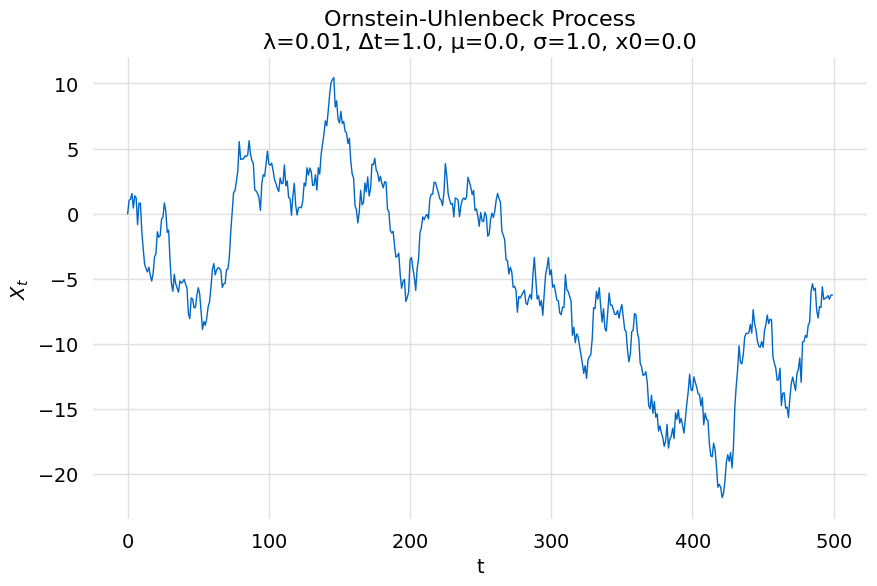

In [172]:
λ = 0.01
Δt = 1.0
μ = 0.0
σ = 1.0
x0 = 0.0
npts = 500
params = {"μ": μ, "λ": λ, "σ": σ, "x0": x0, "npts": npts, "Δt": Δt}
title = f"Ornstein-Uhlenbeck Process\nλ={λ}, Δt={Δt}, μ={μ}, σ={σ}, x0={x0}"
t, xt = ou.create_source(**params)
curve(xt, t, title=title, xlabel="t", ylabel=r"$X_t$", lw=1)

In [173]:
result, result_model = ou.compute_mean_half_life_estimate(xt, Δt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     2.855
Date:                Mon, 11 Dec 2023   Prob (F-statistic):             0.0917
Time:                        11:34:24   Log-Likelihood:                -699.22
No. Observations:                 499   AIC:                             1402.
Df Residuals:                     497   BIC:                             1411.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0659      0.054     -1.216      0.225      -0.173       0.041
x1            -0.0109      0.006     -1.690      0.092      -0.024       0.002
==============================================================================
Omnibus:                        0.290   Durbin-Watson:                   1.983
Prob(Omnibus):                  0.865   Jarque-Bera (JB):                0.197
Skew:                           0.044   Prob(JB):                        0.906
Kurtosis:                       3.044   Cond. No.                         10.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [174]:
print(result_model.to_json(True))

{
   "est_model": "OLS",
   "const": {
      "est": -0.06594504549382627,
      "err": 0.05423955137419,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "56db39bb-46a8-4abe-a66b-25dea04ae898",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -0.010923412467918645,
         "err": 0.00646484695953166,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "56db39bb-46a8-4abe-a66b-25dea04ae898",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.005711578660091088,
   "param_transforms": [
      {
         "param": {
            "est": 63.45518697528576,
            "err": 37.554937505884936,
            "est_label": "$t_H$",
            "err_label": "$\\sigma_{t_H}$",
            "row": 0,
            "column": 0,
            "order": 1,
            "

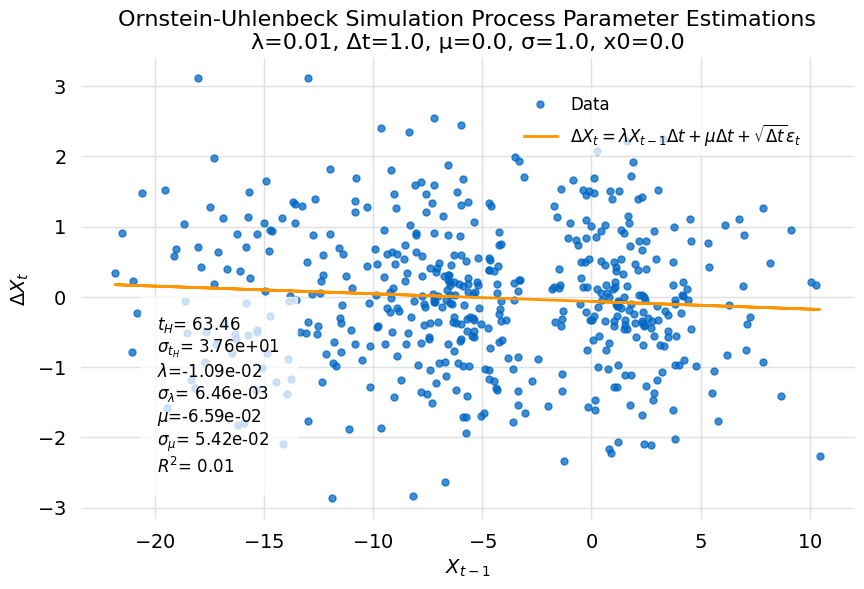

In [175]:
title = f"Ornstein-Uhlenbeck Simulation Process Parameter Estimations\nλ={λ}, Δt={Δt}, μ={μ}, σ={σ}, x0={x0}"
mean_reversion_halflife(xt, result_model, title=title)

## Nonezero Mean

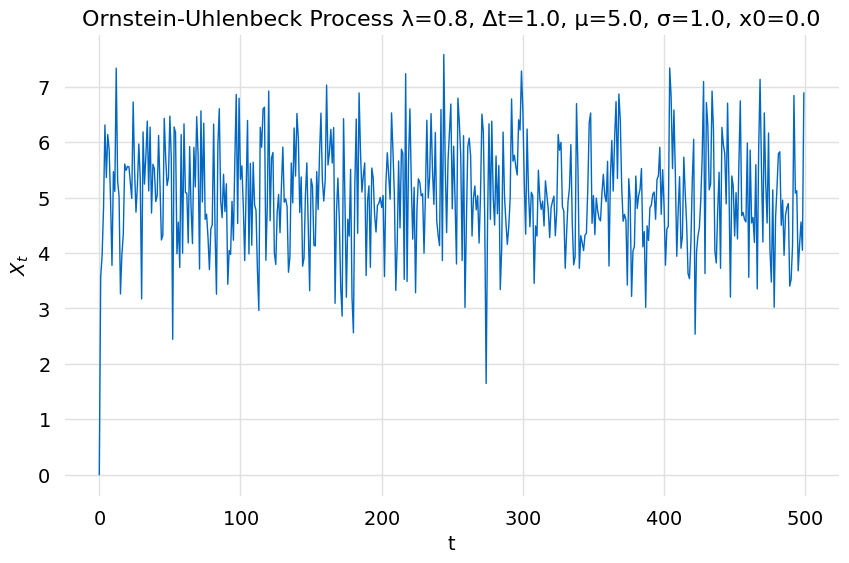

In [176]:
λ = 0.8
Δt = 1.0
μ = 5.0
σ = 1.0
x0 = 0.0
npts = 500
params = {"μ": μ, "λ": λ, "σ": σ, "x0": x0, "npts": npts, "Δt": Δt}
title = f"Ornstein-Uhlenbeck Process λ={λ}, Δt={Δt}, μ={μ}, σ={σ}, x0={x0}"
t, xt = ou.create_source(**params)
curve(xt, t, title=title, xlabel="t", ylabel=r"$X_t$", lw=1)

In [177]:
result, result_model = ou.compute_mean_half_life_estimate(xt, Δt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.456
Method:                 Least Squares   F-statistic:                     418.3
Date:                Mon, 11 Dec 2023   Prob (F-statistic):           6.55e-68
Time:                        11:34:25   Log-Likelihood:                -691.62
No. Observations:                 499   AIC:                             1387.
Df Residuals:                     497   BIC:                             1396.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.5015      0.224     20.126      0.000       4.062       4.941
x1            -0.8912      0.044    -20.453      0.000      -0.977      -0.806
==============================================================================
Omnibus:                        0.239   Durbin-Watson:                   2.003
Prob(Omnibus):                  0.887   Jarque-Bera (JB):                0.342
Skew:                          -0.034   Prob(JB):                        0.843
Kurtosis:                       2.891   Cond. No.                         27.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [178]:
print(result_model.to_json(True))

{
   "est_model": "OLS",
   "const": {
      "est": 4.501499564328969,
      "err": 0.2236683231185085,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "8beb7671-2ae0-4cc5-8cc9-d43a25863e5c",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -0.8912322319537126,
         "err": 0.043574972744805374,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "8beb7671-2ae0-4cc5-8cc9-d43a25863e5c",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.4570198625589885,
   "param_transforms": [
      {
         "param": {
            "est": 0.7777402518762864,
            "err": 0.03802601506428391,
            "est_label": "$t_H$",
            "err_label": "$\\sigma_{t_H}$",
            "row": 0,
            "column": 0,
            "order": 1,
            "es

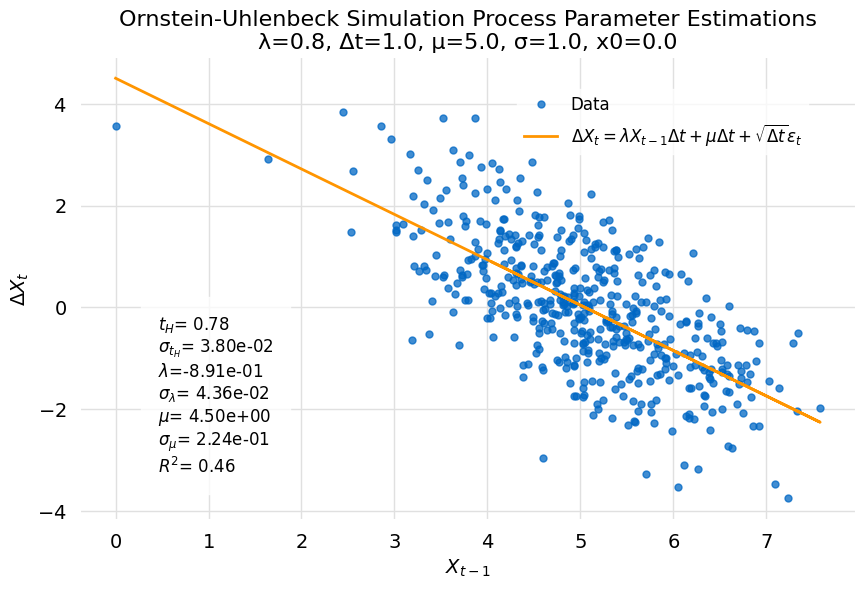

In [179]:
title = f"Ornstein-Uhlenbeck Simulation Process Parameter Estimations\nλ={λ}, Δt={Δt}, μ={μ}, σ={σ}, x0={x0}"
mean_reversion_halflife(xt, result_model, title=title)